<span style="color:pink; font-size:20px;">File to get plots for Ergotropic Changes vs Correlation Measures of Initial States.</span>

In [ ]:
# Import necessary libraries and modules
import random
import numpy as np
import matplotlib.pyplot as plt
from state_gen import generate_state
from energy import energy, passive_energy_g, passive_energy_l, ergotropy_gap, global_ergo, local_ergo
from local_to import gibbs_states, qubit_ham, LTO_step
from unitary import deg_unitary
from lin_alg import negativity, partial_trace, vn_entropy, rel_entropy, passive_state
from tqdm import tqdm

In [ ]:
# Set parameters for the simulation

# Qubit hamiltonian parameters (energy levels)
w1=1.0
w2=2.0
w3=1.5 #1.0 #1.5
w4=0.5 #2.0 #0.5

# Inverse temperatures for the baths
beta_a=1.0
beta_b=2.0

# Parameters for state generation and simulation
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

# Dictionary to map state generation types to their string representations
kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

In [ ]:
# --- Simulation for many initial states and optimal unitary (random sampling) ---

def simulate_and_plot(kind="product", n_samples=200, num_states=100):

    Rg_lto_list, Rl_lto_list = [], []
    gbound_list_states, lbound_list_states = [], []
    neg_list, R_gap_ini, R_gap_sigma = [], [], []

    # ----- Baths (precompute once) -----
    gamma_a, gamma_b = gibbs_states(beta_a, beta_b, w3, w4)

    Hs1 = qubit_ham(w1)
    Hs2 = qubit_ham(w2)
    Hb1 = qubit_ham(w3)
    Hb2 = qubit_ham(w4)
    
    # ----- Sampling loop -----
    for i in tqdm(range(num_states), desc="State samples", leave=False):

        kind = random.choice(["pure_ent", "mixed_ent"])

        # ----- Initial state -----
        rho12 = generate_state(kind, a=a, n_terms=n_terms, p=p)
        Rg_lto, Rl_lto, R_gap = [], [], []
        gbound_list = []

        # ---- reduced states ----
        rho1 = partial_trace(rho12, sys=1)
        rho2 = partial_trace(rho12, sys=0)
        pass_rho_1 = passive_state(rho1)
        pass_rho_2 = passive_state(rho2)

        # ----- initial observables ----
        neg_list.append(negativity(rho12))

        E0 = energy(rho12, w1, w2)
        Rg0 = E0 - passive_energy_g(rho12, w1, w2)
        Rl0 = E0 - passive_energy_l(rho12, w1, w2)

        # ---- local bound ----
        bound_l = rel_entropy(pass_rho_1, gamma_a)/beta_a + rel_entropy(pass_rho_2, gamma_b)/beta_b

        # Running for n_samples iterations to find the optimal unitaries that maximize the ergotropic changes under LTOs
        for _ in range(n_samples):

            Ua = deg_unitary(Hs1, Hb1)
            Ub = deg_unitary(Hs2, Hb2)

            sigma, _, _ = LTO_step(rho12, gamma_a, gamma_b, Ua, Ub)

            # ---- observables ----
            E_sigma = energy(sigma, w1, w2)
            Rg = E_sigma - passive_energy_g(sigma, w1, w2)
            Rl = E_sigma - passive_energy_l(sigma, w1, w2)

            Rg_lto.append(Rg)
            Rl_lto.append(Rl)
            R_gap.append(Rg - Rl)

            # ---- reduced states ----
            sigma1 = partial_trace(sigma, sys=1)
            sigma2 = partial_trace(sigma, sys=0)

            # ---- global correction term ----
            local_term = (1/beta_a) * (vn_entropy(sigma1) - vn_entropy(rho1)) + (1/beta_b) * (vn_entropy(sigma2) - vn_entropy(rho2))
            energy_term = - passive_energy_g(rho12, w1, w2) + passive_energy_g(sigma, w1, w2)
            bound_g = energy_term + local_term

            # if _ < 5: print(bound_l, E_bound_g, local_term)
            gbound_list.append(bound_g)
        
        Rg_lto_list.append(max(Rg_lto)-Rg0)
        Rl_lto_list.append(max(Rl_lto)-Rl0)
        R_gap_ini.append(Rg0 - Rl0)
        R_gap_sigma.append(min(R_gap))
        gbound_list_states.append(max(gbound_list))
        lbound_list_states.append(bound_l)

    return (neg_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma)
    

In [10]:
def plot_lto_results(neg_list, gbound_list, lbound_list, Rg_lto, Rl_lto, R_gap_ini, R_gap_sigma,
    # ── aesthetic controls ────────────────────────────────────────
    figsize        = (10, 7),
    marker_size    = 30,
    alpha          = 0.55,
    marker         = 'o',
    bound_marker   = '^',
    font_size      = 11,
    title_size     = 12,
    legend_size    = 9,
    tick_size      = 9,
    linewidth      = 0.4,       # scatter edge linewidth
    dpi            = 120,
    palette        = None,
    suptitle       = None,
    save_path      = None,
):
    """
    2×2 professional visualization of LTO ergotropy behaviour vs negativity.

    Parameters
    ----------
    neg_list      : negativity of initial states
    gbound_list   : global ergotropy bound per state
    lbound_list   : local ergotropy bound per state
    Rg_lto        : ΔRg = Rg(σ) - Rg(ρ) per state
    Rl_lto        : ΔRl = Rl(σ) - Rl(ρ) per state
    R_gap_ini     : initial ergotropy gap Rl - Rg per state
    R_gap_sigma   : post-LTO ergotropy gap per state
    """

    # ── default palette ───────────────────────────────────────────
    if palette is None:
        palette = {
            'global'  : '#2196F3',   # blue
            'local'   : '#4CAF50',   # green
            'gap_ini' : '#9E9E9E',   # grey
            'gap_sig' : '#FF5722',   # deep orange
            'gbound'  : "#F62415",   # red
            'lbound'  : '#9C27B0',   # purple
        }

    # ── convert to arrays ─────────────────────────────────────────
    neg         = np.array(neg_list)
    Rg          = np.array(Rg_lto)
    Rl          = np.array(Rl_lto)
    gap_ini     = np.array(R_gap_ini)
    gap_sig     = np.array(R_gap_sigma)
    gbound      = np.array(gbound_list)
    lbound      = np.array(lbound_list)
    sort_idx    = np.argsort(neg)

    # ── shared scatter kwargs ─────────────────────────────────────
    def skw(color, marker=marker):
        return dict(s=marker_size, color=color, alpha=alpha,
                    marker=marker, linewidths=linewidth,
                    edgecolors='white', zorder=3)

    def bkw(color):   # bound marker kwargs
        return dict(s=marker_size*0.8, color=color, alpha=alpha*0.85,
                    marker=bound_marker, linewidths=linewidth,
                    edgecolors='white', zorder=4)

    # ── figure ────────────────────────────────────────────────────
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(3, 2, figsize=(figsize[0], figsize[1]*1.5), dpi=dpi)
    axs[2, 1].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=title_size + 1, fontweight='bold', y=1.01)

    # helper: shared axis styling
    def style(ax, xlabel, ylabel, title):
        ax.set_xlabel(xlabel,  fontsize=font_size)
        ax.set_ylabel(ylabel,  fontsize=font_size)
        ax.set_title(title,    fontsize=title_size, fontweight='semibold', pad=8)
        ax.tick_params(labelsize=tick_size)
        ax.axhline(0, color='#BDBDBD', linewidth=0.9,
                   linestyle='--', zorder=1)
        ax.legend(fontsize=legend_size, frameon=True,
                  framealpha=0.85, edgecolor='#E0E0E0')

    # ── Panel (0,0): ΔRg vs negativity ───────────────────────────
    ax = axs[0, 0]
    ax.scatter(neg, Rg,     label=r"$\Delta R_g$",       **skw(palette['global']))
    ax.scatter(neg, gbound, label=r"Global bound (exp.)", **bkw(palette['gbound']))
    style(ax, xlabel=r"Negativity $\mathcal{N}$", ylabel=r"$\Delta R_{\rm global}$", title=r"Global Ergotropy Change vs $\mathcal{N}$")

    # ── Panel (0,1): ΔRl vs negativity ───────────────────────────
    ax = axs[0, 1]
    ax.scatter(neg, Rl,     label=r"$\Delta R_l$",   **skw(palette['local']))
    ax.scatter(neg, lbound, label=r"Local bound",     **bkw(palette['lbound']))
    style(ax, xlabel=r"Negativity $\mathcal{N}$", ylabel=r"$\Delta R_{\rm local}$", title=r"Local Ergotropy Change vs $\mathcal{N}$")

    # ── Panel (1,0): ergotropy gap vs negativity ─────────────────
    ax = axs[1, 0]
    ax.scatter(neg, gap_ini, label=r"$R_g - R_l$ (initial)",   **skw(palette['gap_ini']))
    ax.scatter(neg, gap_sig, label=r"$R_g - R_l$ (after LTO)", **skw(palette['gap_sig']))
    style(ax, xlabel=r"Negativity $\mathcal{N}$", ylabel=r"$R_g - R_l$", title=r"Ergotropy Gap vs $\mathcal{N}$")

    # ── Panel (1,1): ΔRg vs ΔRl scatter ─────────────────────────
    ax = axs[1, 1]
    sc = ax.scatter(Rg, Rl, c=neg, cmap='viridis', s=marker_size, alpha=alpha, linewidths=linewidth, edgecolors='white', zorder=3)
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r"Negativity $\mathcal{N}$", fontsize=font_size - 1)
    cbar.ax.tick_params(labelsize=tick_size - 1)

    # diagonal reference: ΔRg = ΔRl
    lims = [min(Rg.min(), Rl.min()) - 0.01, max(Rg.max(), Rl.max()) + 0.01]
    ax.plot(lims, lims, color='#BDBDBD', linewidth=0.9, linestyle='--', zorder=1, label=r"$\Delta R_g = \Delta R_l$")
    ax.set_xlim(lims);  ax.set_ylim(lims)
    style(ax, xlabel=r"$\Delta R_{\rm global}$", ylabel=r"$\Delta R_{\rm local}$", title=r"$\Delta R_{\rm global}$ vs $\Delta R_{\rm local}$")

    # ── Panel (2,0): ΔRg vs ΔRl with bounds overlaid ─────────────
    ax = axs[2, 0]

    # scatter data points colored by negativity
    sc2 = ax.scatter(Rg, Rl, c=neg, cmap='viridis', s=marker_size, alpha=alpha, linewidths=linewidth, edgecolors='white', zorder=3)
    cbar2 = fig.colorbar(sc2, ax=ax, pad=0.02)
    cbar2.set_label(r"Negativity $\mathcal{N}$", fontsize=font_size - 1)
    cbar2.ax.tick_params(labelsize=tick_size - 1)

    # diagonal reference ΔRg = ΔRl
    lims2 = [min(Rg.min(), Rl.min()) - 0.01, max(Rg.max(), Rl.max()) + 0.01]
    ax.plot(lims2, lims2, color='#BDBDBD', linewidth=0.9, linestyle='--', zorder=1, label=r"$\Delta R_g = \Delta R_l$")

    # global bound on x-axis: scatter gbound vs lbound
    ax.scatter(gbound, lbound, marker=bound_marker, s=marker_size*0.9, color=palette['gbound'], alpha=alpha*0.85, 
            linewidths=linewidth, edgecolors='white', zorder=4, label=r"(Global bound, Local bound)")

    # vertical line at x=0 and horizontal at y=0
    ax.axvline(0, color='#BDBDBD', linewidth=0.9, linestyle=':', zorder=1)

    ax.set_xlim(lims2);  ax.set_ylim(lims2)
    style(ax, xlabel=r"$\Delta R_{\rm global}$", ylabel=r"$\Delta R_{\rm local}$", title=r"$\Delta R_{\rm global}$ vs $\Delta R_{\rm local}$")

    # ── layout and save ───────────────────────────────────────────
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
        print(f"  Saved → {save_path}")

    plt.show()

    # ── summary stats ─────────────────────────────────────────────
    print("\n" + "─"*50)
    print("  PLOT SUMMARY")
    print("─"*50)
    print(f"  N states    : {len(neg)}")
    print(f"  Neg range   : [{neg.min():.4f}, {neg.max():.4f}]")
    print(f"  ΔRg         : mean={Rg.mean():.4f}  max={Rg.max():.4f}")
    print(f"  ΔRl         : mean={Rl.mean():.4f}  max={Rl.max():.4f}")
    print(f"  Gap(σ)      : mean={gap_sig.mean():.4f}  max={gap_sig.max():.4f}")
    n_viol = np.sum(Rl > lbound + 1e-8)
    print(f"  Local bound violations: {n_viol} / {len(neg)}")
    print("─"*50)

In [ ]:
# Redefined parameters for fresh runs
w1=1.0
w2=2.0
w3=1.5 #1.0 #1.5
w4=0.5 #2.0 #0.5
beta_a=1.0
beta_b=2.0
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

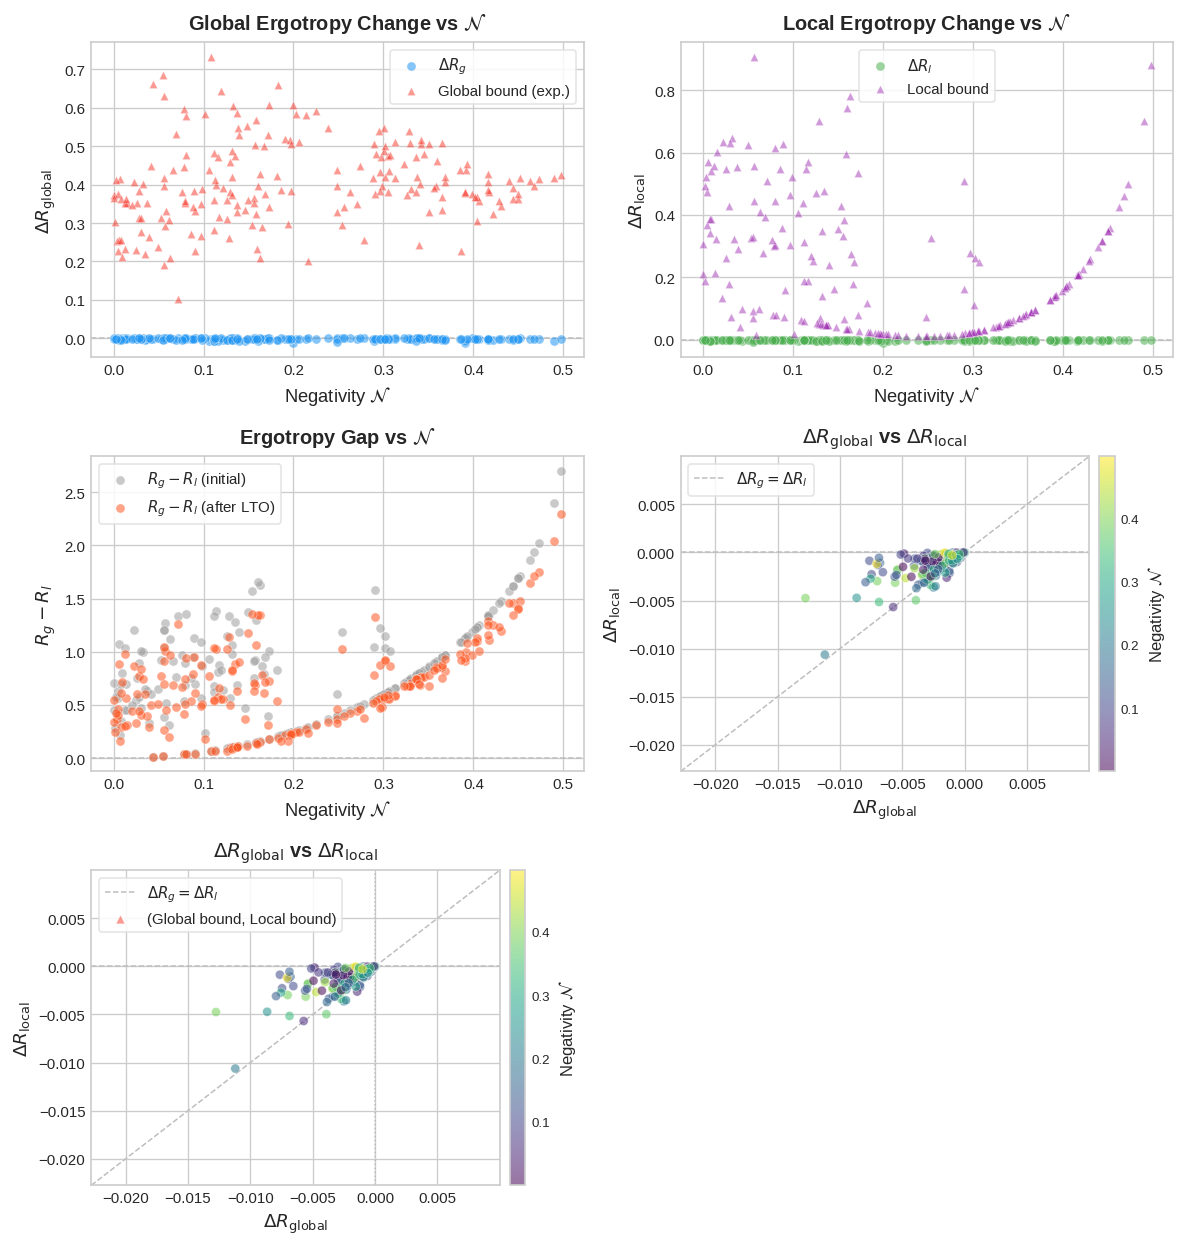


──────────────────────────────────────────────────
  PLOT SUMMARY
──────────────────────────────────────────────────
  N states    : 200
  Neg range   : [0.0000, 0.4975]
  ΔRg         : mean=-0.0021  max=-0.0000
  ΔRl         : mean=-0.0011  max=-0.0000
  Gap(σ)      : mean=0.6749  max=2.2923
  Local bound violations: 0 / 200
──────────────────────────────────────────────────


In [ ]:
# Run the simulation and plot results for a specific state type (e.g., "random")
(neg_list, gbound_list_states, lbound_list_states, 
 Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma) = simulate_and_plot(kind=kind_dict[7], n_samples=200, num_states=200)

plot_lto_results(neg_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma)

In [ ]:
# --- Simulation for many initial states and fixed/random unitary ---

def simulate_fixed_unitary(kind="product", uni_type = "fixed", num_states=100):

    Rg_lto_list, Rl_lto_list = [], []
    gbound_list_states, lbound_list_states = [], []
    neg_list, R_gap_ini, R_gap_sigma = [], [], []

    # ----- Baths (precompute once) -----
    gamma_a, gamma_b = gibbs_states(beta_a, beta_b, w3, w4)

    Hs1 = qubit_ham(w1)
    Hs2 = qubit_ham(w2)
    Hb1 = qubit_ham(w3)
    Hb2 = qubit_ham(w4)

    if uni_type == "fixed":
        Ua = deg_unitary(Hs1, Hb1)
        Ub = deg_unitary(Hs2, Hb2)

    # ----- Sampling loop -----
    for i in tqdm(range(num_states), desc="State samples", leave=False):

        # kind = random.choice(["pure_ent", "mixed_ent"])

        # ----- Initial state -----
        rho12 = generate_state(kind, a=a, n_terms=n_terms, p=p)

        # ---- reduced states ----
        rho1 = partial_trace(rho12, sys=1)
        rho2 = partial_trace(rho12, sys=0)
        pass_rho_1 = passive_state(rho1)
        pass_rho_2 = passive_state(rho2)

        # ----- initial observables ----
        neg_list.append(negativity(rho12))

        Rg0 = global_ergo(rho12, w1, w2)
        Rl0 = local_ergo(rho12, w1, w2)
        R_gap0 = ergotropy_gap(rho12, w1, w2)

        # ---- local bound ----
        bound_l = rel_entropy(pass_rho_1, gamma_a)/beta_a + rel_entropy(pass_rho_2, gamma_b)/beta_b

        if uni_type != "fixed":
            Ua = deg_unitary(Hs1, Hb1)
            Ub = deg_unitary(Hs2, Hb2)

        sigma, _, _ = LTO_step(rho12, gamma_a, gamma_b, Ua, Ub)

        # ---- observables ----
        Rg = global_ergo(sigma, w1, w2)
        Rl = local_ergo(sigma, w1, w2)
        R_gap = ergotropy_gap(sigma, w1, w2)

        # ---- reduced states ----
        sigma1 = partial_trace(sigma, sys=1)
        sigma2 = partial_trace(sigma, sys=0)

        # ---- global correction term ----
        local_term = (1/beta_a) * (vn_entropy(sigma1) - vn_entropy(rho1)) + (1/beta_b) * (vn_entropy(sigma2) - vn_entropy(rho2))
        energy_term = - passive_energy_g(rho12, w1, w2) + passive_energy_g(sigma, w1, w2)
        bound_g = energy_term + local_term
        
        Rg_lto_list.append(Rg - Rg0)
        Rl_lto_list.append(Rl - Rl0)
        R_gap_ini.append(R_gap0)
        R_gap_sigma.append(R_gap)
        gbound_list_states.append(bound_g)
        lbound_list_states.append(bound_l)

    return (neg_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma)
    

In [14]:
w1=1.0
w2=2.0
w3=1.5 #1.0 #1.5
w4=0.5 #2.0 #0.5
beta_a=1.0
beta_b=2.0
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

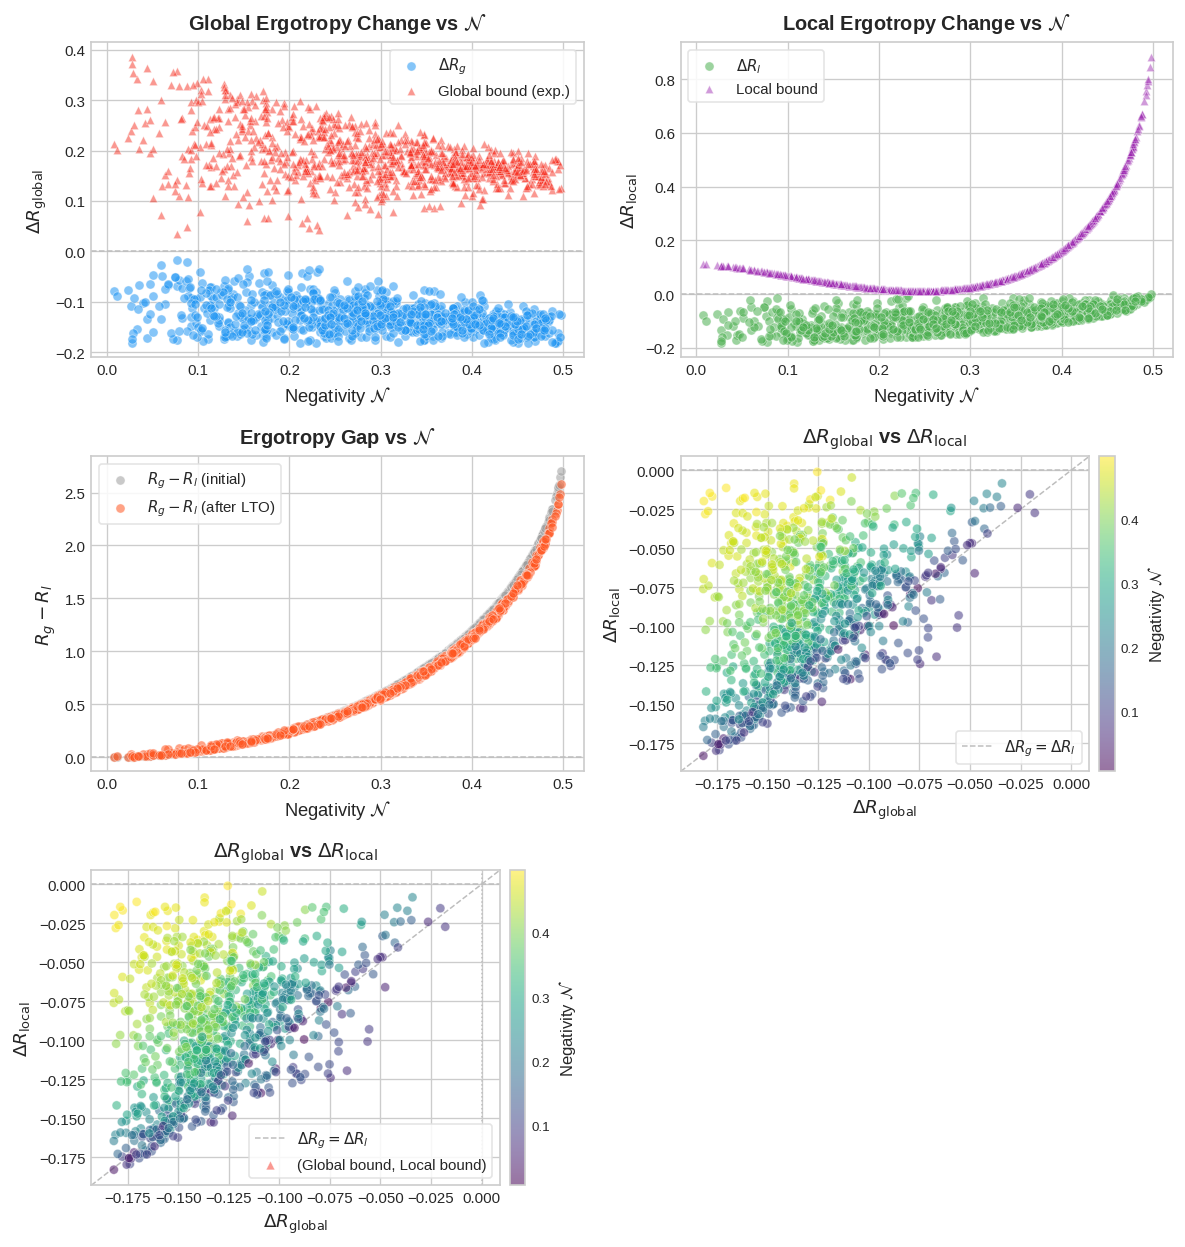


──────────────────────────────────────────────────
  PLOT SUMMARY
──────────────────────────────────────────────────
  N states    : 1000
  Neg range   : [0.0075, 0.4976]
  ΔRg         : mean=-0.1291  max=-0.0180
  ΔRl         : mean=-0.0908  max=-0.0010
  Gap(σ)      : mean=0.7230  max=2.5830
  Local bound violations: 0 / 1000
──────────────────────────────────────────────────


In [15]:
(neg_list, gbound_list_states, lbound_list_states, 
 Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma) = simulate_fixed_unitary(kind=kind_dict[4], uni_type="fixed", num_states=1000)

plot_lto_results(neg_list, gbound_list_states, lbound_list_states, Rg_lto_list, Rl_lto_list, R_gap_ini, R_gap_sigma)